In [1]:
#Importing libraries here
import numpy as np
import pandas as pd

import matplotlib.pyplot  as plt
import seaborn as sns

sns.set_style('whitegrid')

In [2]:
#loading csv data 
df =pd.read_csv('../data/layoffs.csv')

In [3]:
#fetch default first 5 rows of the entire data
df.head()

,company,location,total_laid_off,date,percentage_laid_off,industry,source,stage,funds_raised,country,date_added
0,ClickUp,San Diego,NaN,5/21/2026,0.22,Other,https://x.com/DJ_CURFEW/status/205752238231592...,Series C,537.0,United States,5/21/2026
1,Intuit,SF Bay Area,3000.0,5/20/2026,0.17,Finance,https://www.reuters.com/business/world-at-work...,Post-IPO,18.0,United States,5/20/2026
2,AI21 Labs,"Tel Aviv, Non-U.S.",110.0,5/18/2026,0.61,AI,https://en.globes.co.il/en/article-shashuas-ai...,Series D,626.0,Israel,5/20/2026
3,Kraken,SF Bay Area,150.0,5/15/2026,NaN,Crypto,https://www.bloomberg.com/news/articles/2026-0...,Unknown,134.0,United States,5/15/2026
4,Innovaccer,SF Bay Area,340.0,5/14/2026,NaN,Healthcare,https://inc42.com/buzz/exclusive-healthtech-un...,Series E,379.0,United States,5/16/2026


In [4]:
# all columns present in csv
df.columns

Index(['company', 'location', 'total_laid_off', 'date', 'percentage_laid_off',
       'industry', 'source', 'stage', 'funds_raised', 'country', 'date_added'],
      dtype='str')

In [5]:
# number of rows X columns
df.shape

(4418, 11)

In [6]:
# info() provides data type
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4418 entries, 0 to 4417
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   company              4418 non-null   str    
 1   location             4417 non-null   str    
 2   total_laid_off       2895 non-null   float64
 3   date                 4418 non-null   str    
 4   percentage_laid_off  2782 non-null   float64
 5   industry             4416 non-null   str    
 6   source               4415 non-null   str    
 7   stage                4413 non-null   str    
 8   funds_raised         3907 non-null   float64
 9   country              4416 non-null   str    
 10  date_added           4418 non-null   str    
dtypes: float64(3), str(8)
memory usage: 379.8 KB


In [7]:
# basic statistics on data like mean, median & max
df.describe()

,total_laid_off,percentage_laid_off,funds_raised
count,2895.000000,2782.000000,3907.000000
mean,317.159931,0.293295,857.521857
std,1200.264773,0.303222,4568.021464
min,3.000000,0.000000,0.700000
25%,40.000000,0.100000,55.000000
50%,90.000000,0.170000,175.000000
75%,200.000000,0.330000,483.000000
max,30000.000000,1.000000,121900.000000


In [8]:
# transpose
df.describe().T

,count,mean,std,min,25%,50%,75%,max
total_laid_off,2895.0,317.159931,1200.264773,3.0,40.0,90.00,200.00,30000.0
percentage_laid_off,2782.0,0.293295,0.303222,0.0,0.1,0.17,0.33,1.0
funds_raised,3907.0,857.521857,4568.021464,0.7,55.0,175.00,483.00,121900.0


In [9]:
# sum of null values column wise
df.isnull().sum()

company                   0
location                  1
total_laid_off         1523
date                      0
percentage_laid_off    1636
industry                  2
source                    3
stage                     5
funds_raised            511
country                   2
date_added                0
dtype: int64

In [10]:
# total null values in data
df.isnull().sum().sum()

np.int64(3683)

In [11]:
# random sample of size 5
df.sample(5)

,company,location,total_laid_off,date,percentage_laid_off,industry,source,stage,funds_raised,country,date_added
2897,Argo AI,Pittsburgh,173.0,10/26/2022,NaN,Transportation,https://www.autonews.com/mobility-report/argo-...,Unknown,3600.0,United States,10/26/2022
1208,Sierra Space,Boulder,115.0,11/16/2023,NaN,Aerospace,https://www.cnbc.com/2023/11/16/sierra-space-l...,Series B,1700.0,United States,11/17/2023
1885,Astronomer,Cincinnati,100.0,4/13/2023,0.40,Data,Internal memo,Series C,282.0,United States,4/15/2023
1845,Extramarks,"Noida, Non-U.S.",300.0,4/26/2023,NaN,Education,https://inc42.com/buzz/exclusive-reliance-back...,Unknown,NaN,India,4/26/2023
3881,Gojek,"Jakarta, Non-U.S.",430.0,6/23/2020,0.09,Transportation,https://layoffs.fyi/2020/08/06/gojek-creates-t...,Series F,4800.0,Indonesia,6/23/2020


In [12]:
# create a copy to clean the file
df_clean = df.copy()

In [13]:
# check for any duplicate values, if present drop it
df_clean.duplicated().sum()

np.int64(0)

In [14]:
# missing values percentage in desc order
missing_percentage = (df_clean.isnull().sum()/len(df_clean))*100
missing_percentage.sort_values(ascending = False)


percentage_laid_off    37.030330
total_laid_off         34.472612
funds_raised           11.566320
stage                   0.113173
source                  0.067904
country                 0.045269
industry                0.045269
location                0.022635
company                 0.000000
date                    0.000000
date_added              0.000000
dtype: float64

In [15]:
# replacing missing value sin stage column by unknown as the % was less and the column is not much imp
df_clean['stage'].fillna('Unknown')

0       Series C
1       Post-IPO
2       Series D
3        Unknown
4       Series E
          ...   
4413        Seed
4414     Unknown
4415        Seed
4416    Series C
4417    Series A
Name: stage, Length: 4418, dtype: str

In [16]:
# similar to column source, location and industry
df_clean['source'].fillna('Unknown')
df_clean['industry'].fillna('Unknown')
df_clean['location'].fillna('Unknown')

0                San Diego
1              SF Bay Area
2       Tel Aviv, Non-U.S.
3              SF Bay Area
4              SF Bay Area
               ...        
4413           Los Angeles
4414           Los Angeles
4415           SF Bay Area
4416           Los Angeles
4417        Salt Lake City
Name: location, Length: 4418, dtype: str

In [17]:
# checking sample date
df_clean['date'].sample(5)

1654     6/20/2023
1913      4/4/2023
231      9/14/2025
2532    12/16/2022
226      9/25/2025
Name: date, dtype: str

In [18]:
# converting date to date format
df_clean['date'] = pd.to_datetime(df_clean['date'],format = '%m/%d/%Y')
df_clean['year_month'] = df_clean['date'].dt.to_period('M')

In [19]:
# creating cleaned file as csv and loading back to our main folder
df_clean.to_csv('../data/layoff_clean.csv',index = False)

In [20]:
# 1. which company had the most layoffs in the entire time frame
# 2. Similar to country affected max in the layoff
# 3. months where layoffs were maximum
# 4. industry wise analysis /sector 
# 5. at which stage layoffs happened maximum

In [21]:
# use clean data set 
df = pd.read_csv('../data/layoff_clean.csv')
df.columns

Index(['company', 'location', 'total_laid_off', 'date', 'percentage_laid_off',
       'industry', 'source', 'stage', 'funds_raised', 'country', 'date_added',
       'year_month'],
      dtype='str')

In [22]:
# drop added date column to avoid multiple columns created
df = df.drop ('date_added',axis =1)

In [23]:
#final data to be used
df.columns

Index(['company', 'location', 'total_laid_off', 'date', 'percentage_laid_off',
       'industry', 'source', 'stage', 'funds_raised', 'country', 'year_month'],
      dtype='str')

In [24]:
#convert current date to date format
df['date'] = pd.to_datetime(df['date'],format = '%Y-%m-%d')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4418 entries, 0 to 4417
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   company              4418 non-null   str           
 1   location             4417 non-null   str           
 2   total_laid_off       2895 non-null   float64       
 3   date                 4418 non-null   datetime64[us]
 4   percentage_laid_off  2782 non-null   float64       
 5   industry             4416 non-null   str           
 6   source               4415 non-null   str           
 7   stage                4413 non-null   str           
 8   funds_raised         3907 non-null   float64       
 9   country              4416 non-null   str           
 10  year_month           4418 non-null   str           
dtypes: datetime64[us](1), float64(3), str(7)
memory usage: 379.8 KB


In [ ]:
print(f"Data is from {df['date'].min()} to {df['date'].max()}")

Data is from 2020-03-11 00:00:00 to 2026-05-21 00:00:00


The dataset spans from **11 March 2020** to **21 May 2026**, providing over six years of reported layoff data.

In [26]:
# total layoffs
total_layoffs = df['total_laid_off'].sum()
int(total_layoffs)

918178

In [27]:
# max layoff happened
layoffs_max = df['total_laid_off'].max()
layoffs_max

np.float64(30000.0)

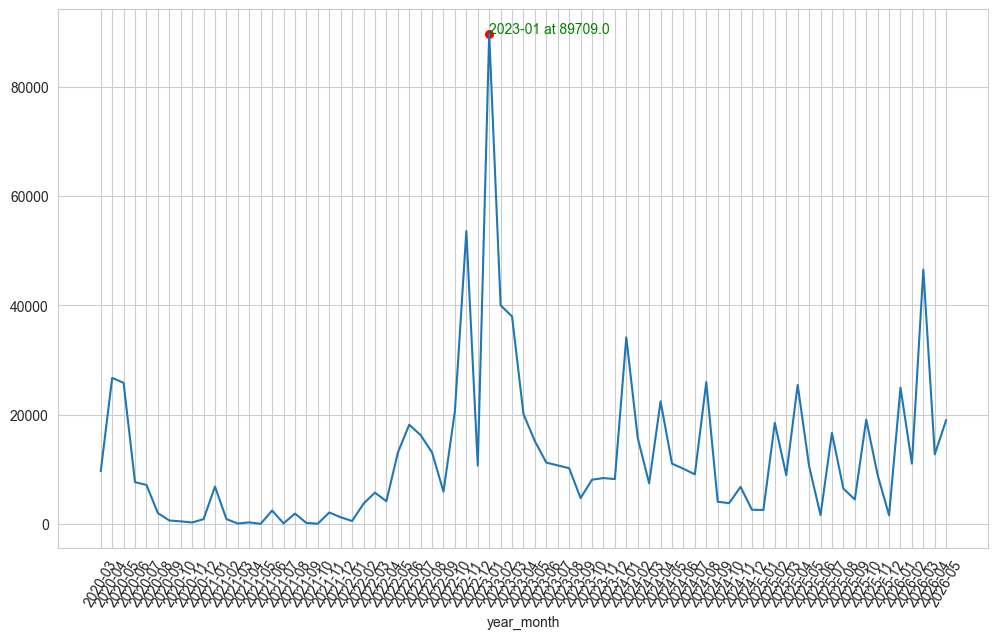

In [42]:
#year_monthly layoffs

monthly_layoffs = df.groupby('year_month')['total_laid_off'].sum()
#plot

plt.figure(figsize=(12,7))

sns.lineplot(
    x=monthly_layoffs.index,
    y=monthly_layoffs.values
)

# find max point
max_idx = np.argmax(monthly_layoffs.values)
max_x = monthly_layoffs.index[max_idx]
max_y = monthly_layoffs.values[max_idx]

# highlight point
plt.scatter(max_x, max_y, color='red', s=30)

# annotate value
plt.text(
    max_x,
    max_y,
    f'{max_x} at {max_y}',
    color='green'
)

plt.xticks(rotation=60)

plt.savefig('monthly_laid_off.png', dpi=400)
plt.show()

Global layoffs peaked in January 2023, with 89,709 employees laid off, making it the highest monthly total in the dataset. This indicates that workforce reductions intensified at the beginning of 2023.

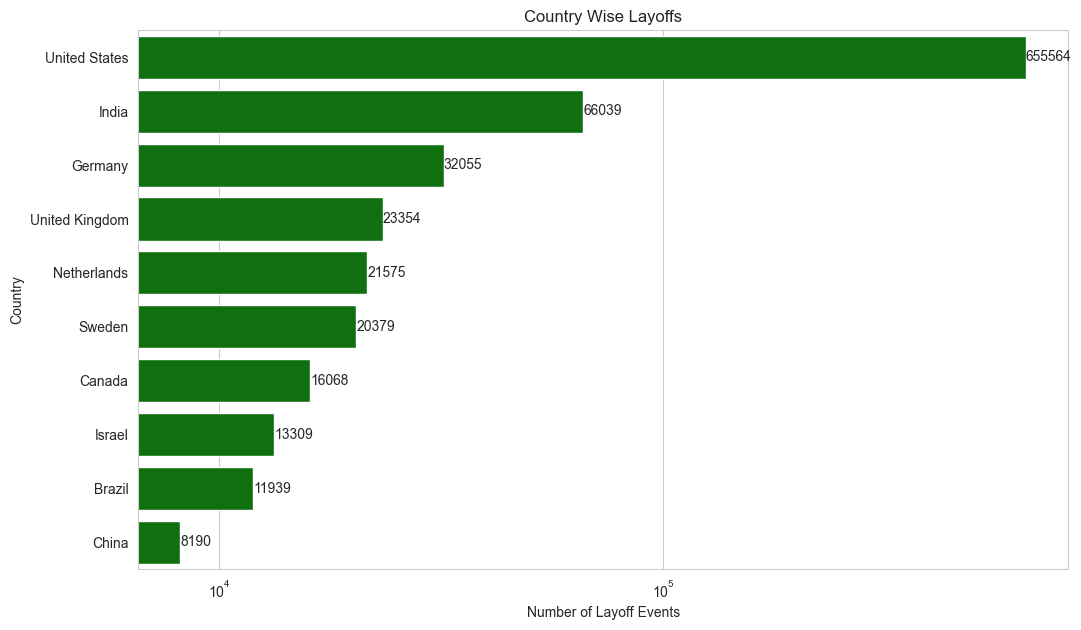

In [ ]:
company_stats = df.groupby('country').agg(
    layoffs_count = ('country','count'), total_layoffs_sum = ('total_laid_off','sum')
    ).sort_values(
       'total_layoffs_sum', ascending=False
    ).head(10)

plt.figure(figsize = (12,7))

ax = sns.barplot(
    y = company_stats.index,
    x = company_stats['total_layoffs_sum'],
    color = 'green'
)

ax.bar_label(ax.containers[0])


plt.xlabel('Number of Layoff Events')
plt.ylabel('Country')
plt.title('Country Wise Layoffs')
plt.xscale('log')

plt.savefig('Country wise layoffs.png',dpi = 400)
plt.show()

The United States recorded the highest total layoffs, significantly exceeding all other countries in the dataset.
India, Germany, the United Kingdom, and the Netherlands also rank among the top five, indicating that workforce reductions affected multiple major economies.

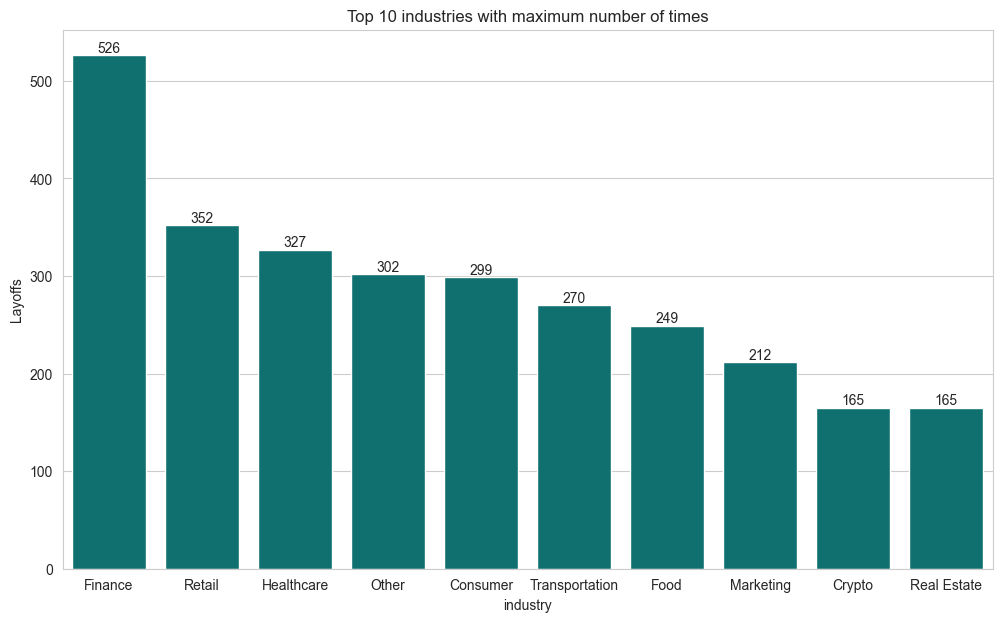

In [75]:
# industry affected most by layoffs
result = df.groupby('industry').agg(
    layoffs_count = ('industry','count'),
    total_layoffs_sum = ('total_laid_off','sum'),
    avg_percentage_layoffs = ('percentage_laid_off','mean')
    ).sort_values(
       'layoffs_count', ascending=False
    ).head(10)
result['avg_percentage_layoffs'] = (result['avg_percentage_layoffs'] * 100).round(2)
result

plt.figure(figsize = (12,7))

ax = sns.barplot(
 x = result.index,
 y = result['layoffs_count'],
 color = 'teal'
)

ax.bar_label(ax.containers[0])

plt.ylabel('Layoffs')
plt.title('Top 10 industries with maximum number of times')
plt.savefig ('Industry wise layoff.png',dpi = 400)
plt.show()


The Finance industry recorded the highest number of layoff events, indicating that companies in this sector announced workforce reductions more frequently than those in any other industry.

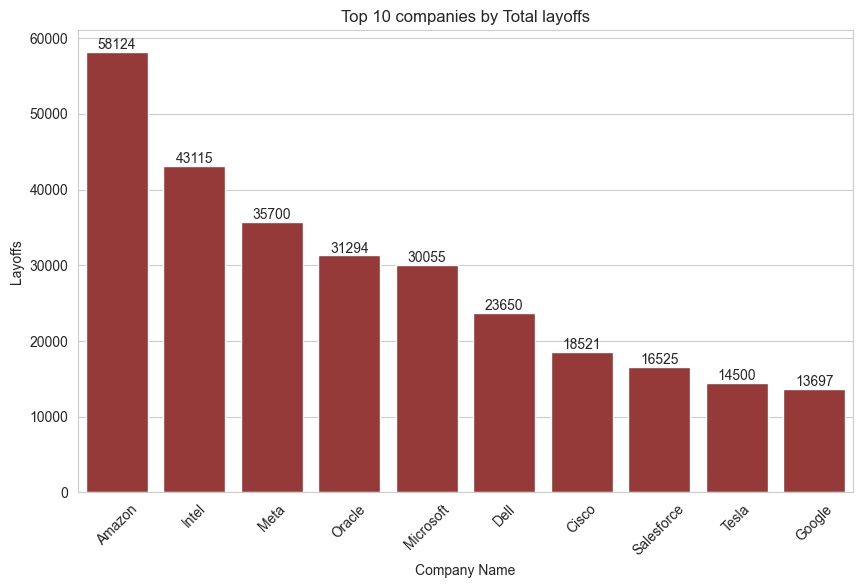

In [77]:
# top 10 companies with lay offs
top_companies = df.groupby('company')['total_laid_off'].sum().sort_values(ascending = False).head(10)


plt.figure(figsize=(10,6))

ax= sns.barplot( 
 x = top_companies.index,
 y= top_companies.values,
 color='brown')

ax.bar_label(ax.containers[0])
plt.xticks(rotation =45)
plt.title('Top 10 companies by Total layoffs')
plt.xlabel('Company Name')
plt.ylabel('Layoffs')
plt.savefig('company_plot.png',dpi =400)

 1. Amazon recorded the highest total number of employees laid off among all companies in the dataset, indicating the largest cumulative workforce reduction.
 2. Several major technology companies dominate the top 10, suggesting the tech sector experienced substantial workforce restructuring during the period.

In [76]:
df.loc[df['percentage_laid_off'] == 1, 'company'].nunique()

346

In [65]:
df.loc[df['percentage_laid_off']==1]['company']

18             Parker
59         Pepper Pay
65      NeuroPixel.AI
72             Covrzy
73           Rec Room
            ...      
4401          Service
4404           Ejento
4408            Popin
4412         Help.com
4413          Service
Name: company, Length: 348, dtype: str

1. Companies with 100% layoffs represent cases where the entire reported workforce was laid off, indicating complete workforce reductions. In many instances, this is associated with company closures, shutdowns, or the cessation of operations.
2. A total of 346 companies reported laying off 100% of their workforce.

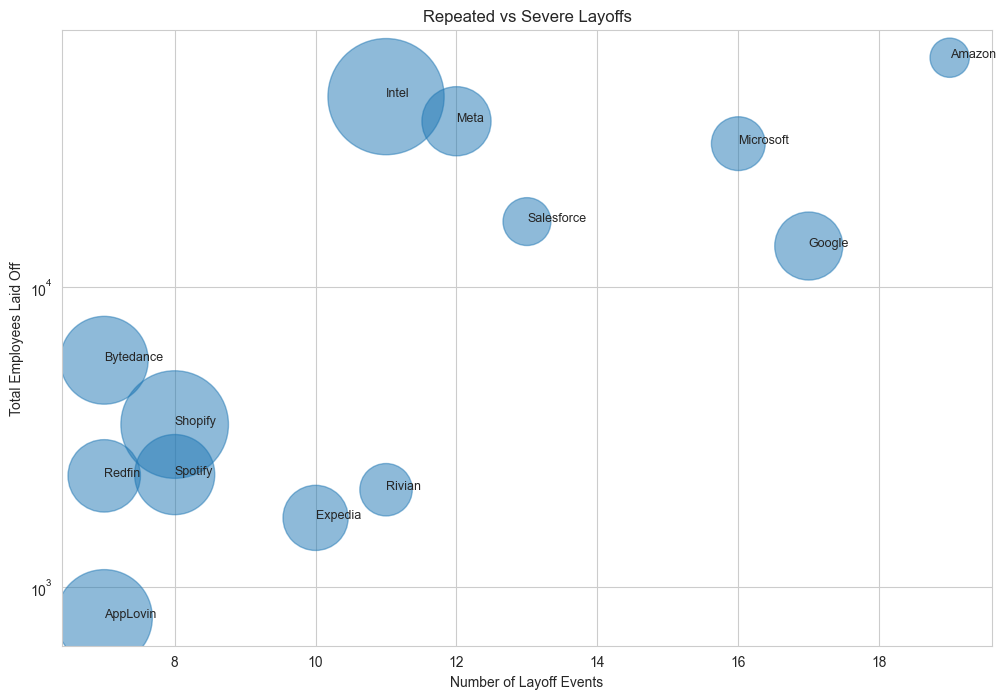

In [33]:
# company wise overview (repeated vs severe layoffs)
result = df.groupby('company').agg(
    layoffs_count = ('company','count'),
    total_layoffs_sum = ('total_laid_off','sum'),
    avg_percentage_layoffs = ('percentage_laid_off','mean')
    ).sort_values(
       'layoffs_count', ascending=False
    ).head(15)
result['avg_percentage_layoffs'] = (result['avg_percentage_layoffs'] * 100).round(2)

#missing values drop
result = result.dropna(subset=['avg_percentage_layoffs'])

plt.figure(figsize=(12,8))

plt.scatter(
    result['layoffs_count'],
    result['total_layoffs_sum'],
    s=result['avg_percentage_layoffs'] * 400,
    alpha = 0.5
)

# company labels
for company, row in result.iterrows():
    plt.text(
        row['layoffs_count'],
        row['total_layoffs_sum'],
        company,
        fontsize=9
    )

plt.xlabel('Number of Layoff Events')
plt.ylabel('Total Employees Laid Off')
plt.title('Repeated vs Severe Layoffs')

plt.yscale('log')  

plt.grid(True)
plt.savefig('Repeated vs Severe Layoffs.png',dpi =400)
plt.show()

1. Amazon appears in the top-right quadrant, indicating that it recorded both a high number of layoff events and a large cumulative number of employees laid off. This suggests layoffs occurred repeatedly and at a significant scale.
2. Intel has one of the largest bubbles on the chart, indicating a higher average percentage of workforce laid off compared with other companies in the top 15. Although it may not have had the highest number of layoff announcements, each layoff affected a relatively larger share of its employees.
3. The chart shows that layoff frequency and layoff severity are different metrics. Some companies announced layoffs multiple times, while others had fewer announcements but reduced a larger proportion of their workforce.
4. Companies positioned higher on the chart experienced larger cumulative workforce reductions, whereas companies farther to the right announced layoffs more frequently.

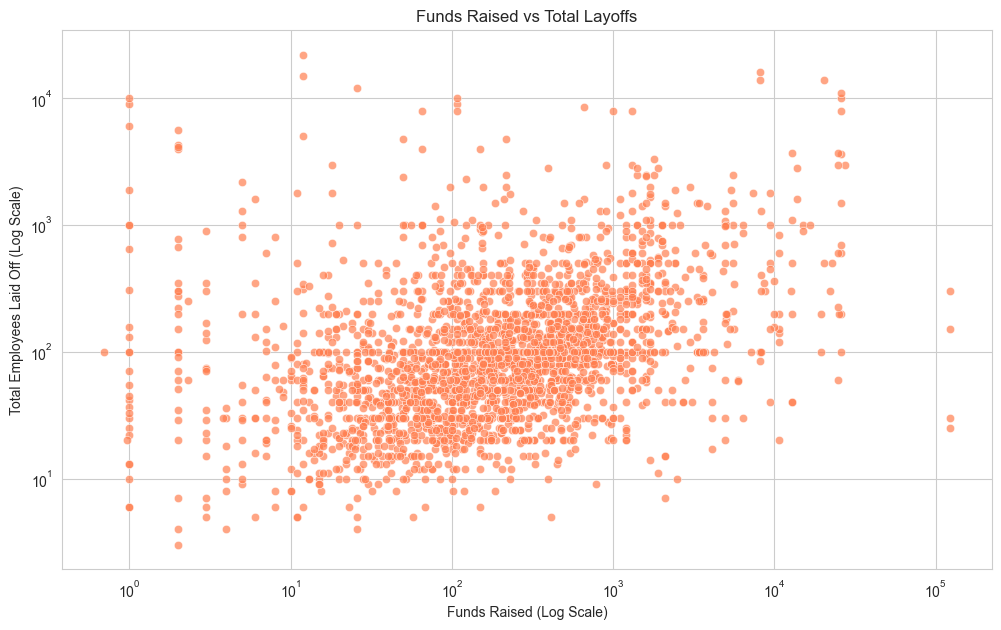

In [36]:
# funds raised vs layoffs
plt.figure(figsize=(12,7))

sns.scatterplot(
    x='funds_raised',
    y='total_laid_off',
    data=df,
    alpha=0.7,
    color = 'coral'
)

plt.xscale('log')
plt.yscale('log')

plt.title('Funds Raised vs Total Layoffs')
plt.xlabel('Funds Raised (Log Scale)')
plt.ylabel('Total Employees Laid Off (Log Scale)')

plt.savefig('funding vs layoffs.png', dpi = 500)
plt.show()


1. A positive relationship is observed between funds raised and total layoffs, indicating that companies raising larger amounts of funding also tended to report larger workforce reductions.
2. Most companies are clustered in the lower-to-middle funding range, where layoffs typically remained below 1,000 employees.
3. Several outliers exist, with highly funded companies reporting 10,000+ layoffs, demonstrating that substantial funding did not necessarily prevent large-scale workforce reductions.